In [52]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression

In [53]:
data={
    'Study_Hours':[2,3,4,5,6,7,8,9],
    'Attendence':[60,65,70,75,80,85,90,95],
    'Assignment_score':[50,55,58,65,70,74,80,88],
    'Final_marks':[42,48,54,61,67,73,81,89]

}

In [54]:
df=pd.DataFrame(data)
df

,Study_Hours,Attendence,Assignment_score,Final_marks
0,2,60,50,42
1,3,65,55,48
2,4,70,58,54
3,5,75,65,61
4,6,80,70,67
5,7,85,74,73
6,8,90,80,81
7,9,95,88,89


In [55]:
x=df[['Study_Hours','Attendence','Assignment_score']]
x

,Study_Hours,Attendence,Assignment_score
0,2,60,50
1,3,65,55
2,4,70,58
3,5,75,65
4,6,80,70
5,7,85,74
6,8,90,80
7,9,95,88


In [56]:
y=df['Final_marks']
y

,Final_marks
0,42
1,48
2,54
3,61
4,67
5,73
6,81
7,89


In [57]:
model = LinearRegression()
model.fit(x,y)

LinearRegression()

In [58]:
print('Intercept:',model.intercept_)


Intercept: -28.31652806652808


In [59]:
#because it is a multiple linaer regression we have 3 coiffeciant
coefficient_tabel=pd.DataFrame({
    'feature': x.columns,
    'coefficient':model.coef_
})

In [60]:
print(coefficient_tabel)

            feature  coefficient
0       Study_Hours     0.131410
1        Attendence     0.657051
2  Assignment_score     0.608108


In [61]:
new_student = pd.DataFrame({
    'Study_Hours':[6],
    'Attendence':[82],
    'Assignment_score':[72]
})


In [62]:
prediction = model.predict(new_student)
print("predicted final mark", prediction[0])

predicted final mark 70.13392238392238


In [63]:
df.to_csv('Study_hours.csv', index=False)

In [64]:
df1=pd.read_csv('Study_hours.csv')
df1

,Study_Hours,Attendence,Assignment_score,Final_marks
0,2,60,50,42
1,3,65,55,48
2,4,70,58,54
3,5,75,65,61
4,6,80,70,67
5,7,85,74,73
6,8,90,80,81
7,9,95,88,89


In [65]:
x=df[['Study_Hours','Attendence','Assignment_score']]
y=df['Final_marks']

In [66]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error,r2_score
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)#random_state to avoid ranodm number each time the cell is executed

In [67]:
model =LinearRegression()
model.fit(x_train,y_train)
y_pred = model.predict(x_test)

In [68]:
print("Intercept :", model.intercept_)
print("Actual values :",y_test.values)
print("Predicted values :",y_pred)

Intercept : -29.244102564102562
Actual values : [48 73]
Predicted values : [48.28       73.69333333]


In [69]:
coefficient = pd.DataFrame({
    'Features':x.columns,
    'coefficient':model.coef_
})
print(coefficient)

           Features  coefficient
0       Study_Hours     0.146923
1        Attendence     0.734615
2  Assignment_score     0.533333


In [70]:
print('Mean absolute error:', mean_absolute_error(y_test,y_pred))
print('Mean Square Error:', mean_squared_error(y_test,y_pred))
print('Root mean square error:', np.sqrt(mean_squared_error(y_test, y_pred)))
print('R2_ score: ', r2_score(y_test,y_pred))

Mean absolute error: 0.4866666666666717
Mean Square Error: 0.27955555555556205
Root mean square error: 0.5287301349039621
R2_ score:  0.9982108444444444


Text(0.5, 1.0, 'Actual vs Predicted Marks')

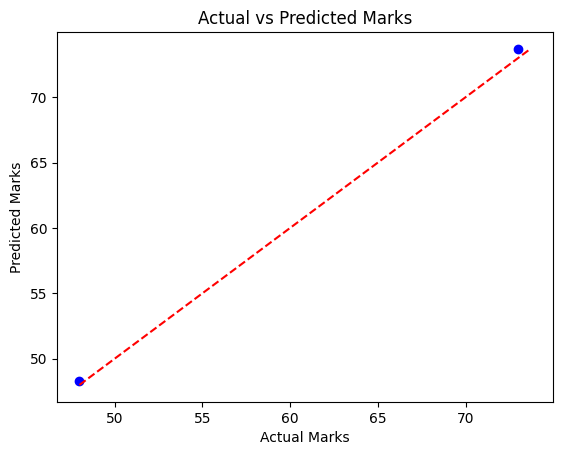

In [71]:
import matplotlib.pyplot as plt

plt.scatter(y_test, y_pred,color='blue')
minimum=min(y_test.min(), y_pred.min())
maximum=max(y_test.max(), y_pred.max())

plt.plot(
    [minimum,maximum],
     [minimum,maximum],
    color='red',
    linestyle='--'
    )
plt.xlabel('Actual Marks')
plt.ylabel('Predicted Marks')
plt.title('Actual vs Predicted Marks')

Residual Plot


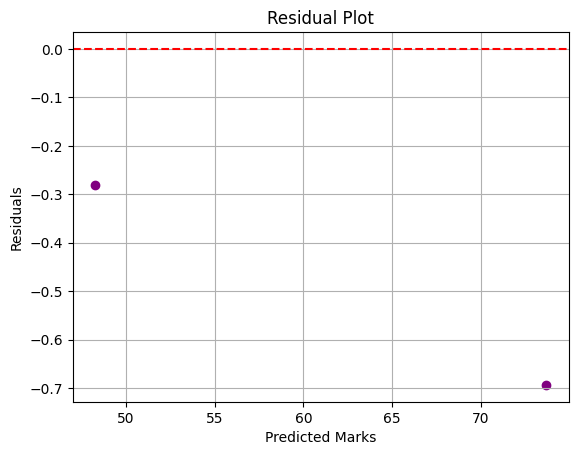

In [72]:
residuals = y_test - y_pred
plt.scatter(y_pred, residuals, color='purple')
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel('Predicted Marks')
plt.ylabel('Residuals')
plt.title('Residual Plot')
plt.grid(True)
plt.show()

Categorical Data

In [73]:
data = {
    'size':[800,1000,1200,1500,1800],
    'Location':['Rural','Urban','Rural','Urban','Urban'],
    'Price':[30,50,42,72,85]
}
df =pd.DataFrame(data)

#another way of label encoding
df_encoded =pd.get_dummies(df,columns=['Location'],drop_first=True,dtype=int)
print(df_encoded)

   size  Price  Location_Urban
0   800     30               0
1  1000     50               1
2  1200     42               0
3  1500     72               1
4  1800     85               1
